### ⚖️ Método: Selección de Acciones con Intervalo de Confianza (UCB)

**Idea principal:**  
El agente elige la acción con mejor balance entre valor conocido `Q(a)`  
y el nivel de incertidumbre de esa acción, usando un intervalo de confianza.

**Donde:**
- \( Q_t(a) \): valor estimado de la acción a.  
- \( N_t(a) \): veces que se ha ejecutado esa acción.  
- \( c \): controla cuánto explora el agente.

**Ventajas:**
- Explora de forma inteligente (no aleatoria).  
- Se adapta automáticamente: explora más al inicio y menos con el tiempo.  

**Desventajas:**
- Requiere llevar la cuenta de cuántas veces se eligió cada acción.  
- El parámetro `c` debe ajustarse correctamente.

**Resultado típico:**  
UCB converge más rápido y de forma más estable que ε-greedy,  
ya que prioriza acciones con alta incertidumbre pero potencial alto.


In [26]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [27]:
GRID_SIZE = 5
ACTIONS = {1: "up", 2: "down", 3: "left", 4: "right", 5: "stay"}


In [28]:

def init_positions():
    head = np.random.randint(0, GRID_SIZE, size=2)
    food = np.random.randint(0, GRID_SIZE, size=2)
    while np.array_equal(head, food):
        food = np.random.randint(0, GRID_SIZE, size=2)
    return head, food

In [29]:
def move(head, action):
    if action == "up": head = head + np.array([-1, 0])
    elif action == "down": head = head + np.array([1, 0])
    elif action == "left": head = head + np.array([0, -1])
    elif action == "right": head = head + np.array([0, 1])
    return head

In [30]:
def get_reward(head, food):
    if np.array_equal(head, food): return 1
    elif np.any(head < 0) or np.any(head >= GRID_SIZE): return -1
    else: return 0

In [31]:
partidas = 1000
turnos = 100
alpha = 0.5
c = 1 # controla el grado de exploración del UCB
epsilons = [0.1, 0.1]  # comparación: UCB vs ε-greedy (igual estructura)
recompensas_medias = np.zeros((len(epsilons), turnos))
acciones_optimas = np.zeros((len(epsilons), turnos))


In [32]:

for ej in range(partidas):
    for i, e in enumerate(epsilons):
        Q = {k: 0 for k in range(1,6)}       # valores iniciales de las acciones
        N = {k: 1 for k in range(1,6)}       # número de veces que se ha elegido cada acción
        head, food = init_positions()
        mejor_accion = 1                     # referencia (arbitraria)

        for exp in range(turnos):
            # --- Selección de acción ---
            if i == 0:  # 🔹 UCB
                maxA = -100
                for j in range(1, 6):
                    ucb_val = Q[j] + c * math.sqrt(math.log(exp + 1.1) / N[j])
                    if ucb_val > maxA:
                        maxA = ucb_val
                        a = j
            else:  # 🔸 ε-greedy (comparativo)
                if np.random.uniform(0, 1) < e:
                    a = np.random.randint(5) + 1
                else:
                    maxQ = -100
                    for j in range(1, 6):
                        if Q[j] > maxQ:
                            maxQ = Q[j]
                            a = j

            # --- Ejecutar acción ---
            new_head = move(head.copy(), ACTIONS[a])
            recompensa = get_reward(new_head, food)
            head = new_head
            N[a] += 1  # actualizar contador de acción

            # --- Actualización incremental ---
            Q[a] += alpha * (recompensa - Q[a])

            # --- Métricas ---
            recompensas_medias[i][exp] += recompensa
            acciones_optimas[i][exp] += (a == mejor_accion)

            # Reinicio si come o choca
            if recompensa != 0:
                head, food = init_positions()


recompensas_medias /= partidas
acciones_optimas /= partidas




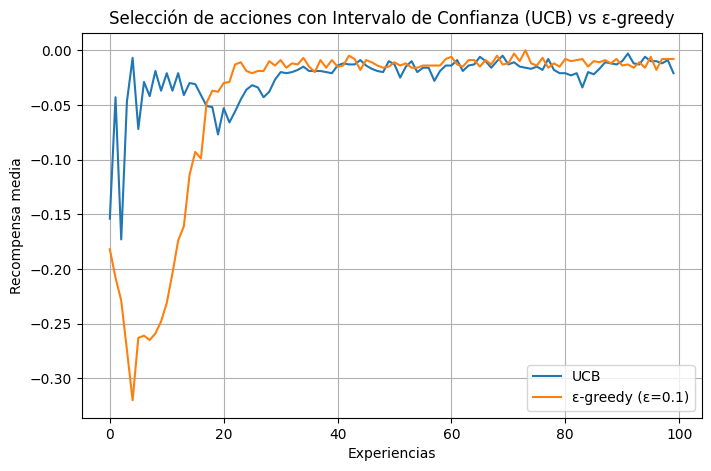

In [33]:
plt.figure(figsize=(8,5))
for i, e in enumerate(epsilons):
    label = "UCB" if i == 0 else f"ε-greedy (ε={e})"
    plt.plot(recompensas_medias[i], label=label)
plt.legend()
plt.grid(True)
plt.xlabel('Experiencias')
plt.ylabel('Recompensa media')
plt.title('Selección de acciones con Intervalo de Confianza (UCB) vs ε-greedy')
plt.show()